In [1]:
pip install pandas matplotlib seaborn langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 981.5/981.5 kB 6.7 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 10.7 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.9 MB 10.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 10.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.0 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect, DetectorFactory

In [14]:


# Cố định seed cho langdetect để kết quả luôn nhất quán mỗi lần chạy
DetectorFactory.seed = 0

# Tên file dữ liệu của bạn
CAPTION_FILE = r'C:\Users\Administrator\Desktop\New folder\dataset\captions_en-vi.csv'

#### Hiểu dữ liệu

In [15]:
# Đọc file, bỏ qua các dòng lỗi format
df = pd.read_csv(CAPTION_FILE, on_bad_lines='skip', encoding='utf-8')

print(f"Tổng số dòng dữ liệu đọc được ban đầu: {len(df)}")

# Kiểm tra missing values
missing_values = df.isnull().sum()
print(f"Số dòng bị thiếu tên ảnh (null image): {missing_values.get('image', 0)}")
print(f"Số dòng bị thiếu caption (null caption): {missing_values.get('caption', 0)}")

# Loại bỏ các dòng bị thiếu dữ liệu để phân tích cho chuẩn xác
df = df.dropna(subset=['image', 'caption']).copy()
print(f"Số dòng sau khi xóa giá trị thiếu: {len(df)}")

# Xem thử 5 dòng đầu tiên
df.head()

Tổng số dòng dữ liệu đọc được ban đầu: 80308
Số dòng bị thiếu tên ảnh (null image): 0
Số dòng bị thiếu caption (null caption): 0
Số dòng sau khi xóa giá trị thiếu: 80308


,image,caption
0,1009434119_febe49276a.jpg,A black and white dog is running in a grassy g...
1,1009434119_febe49276a.jpg,A black and white dog is running through the g...
2,1009434119_febe49276a.jpg,A Boston terrier is running in the grass .
3,1009434119_febe49276a.jpg,A Boston Terrier is running on lush green gras...
4,1009434119_febe49276a.jpg,A dog runs on the green grass near a wooden fe...


In [16]:
# xem 5 dòng cuối 
df.tail()

,image,caption
80303,99171998_7cc800ceef.jpg,Một nhóm đang ngồi xung quanh một khe nứt tuyết
80304,99171998_7cc800ceef.jpg,Một nhóm người ngồi trên đỉnh núi tuyết
80305,99171998_7cc800ceef.jpg,Một nhóm người ngồi trong tuyết rơi trong một ...
80306,99171998_7cc800ceef.jpg,5 đứa sẵn sàng để bắt đầu
80307,99171998_7cc800ceef.jpg,Năm người đang ngồi bên nhau trong tuyết


In [ ]:
def safe_detect(text):
    try:
        lang = detect(str(text))
        if lang == 'vi': return 'Vietnamese'
        elif lang == 'en': return 'English'
        else: return 'Other'
    except:
        return 'Unknown'

# Áp dụng hàm phân loại ngôn ngữ
df['language'] = df['caption'].apply(safe_detect)

# Thống kê số lượng
lang_counts = df['language'].value_counts()
print("Phân bổ ngôn ngữ trong tập dữ liệu:")
print(lang_counts)


Phân bổ ngôn ngữ trong tập dữ liệu:
language
Vietnamese    39812
English       39257
Other          1237
Unknown           2
Name: count, dtype: int64


In [23]:
# Tạo cột mới đếm số từ trong caption
df['word_count'] = df['caption'].astype(str).apply(lambda x: len(x.split()))

print(f"Độ dài caption ngắn nhất (Min): {df['word_count'].min()} từ")
print(f"Độ dài caption dài nhất (Max): {df['word_count'].max()} từ")
print(f"Độ dài trung bình (Mean): {round(df['word_count'].mean(), 2)} từ")

# Tìm Outliers (ngoại lai)
too_short = len(df[df['word_count'] < 10])
print(f"\n=> Cảnh báo Outliers: Có {too_short} câu quá ngắn (<3 từ) và {too_long} câu quá dài (>75 từ).")

Độ dài caption ngắn nhất (Min): 1 từ
Độ dài caption dài nhất (Max): 510 từ
Độ dài trung bình (Mean): 12.83 từ

=> Cảnh báo Outliers: Có 22691 câu quá ngắn (<3 từ) và 79 câu quá dài (>75 từ).


#### Kiểm tra mức độ phân bổ Caption / Ảnh

In [24]:
caps_per_img = df['image'].value_counts()

print(f"Tổng số ảnh ĐỘC NHẤT có trong file text: {len(caps_per_img)} ảnh")
print(f"Trung bình mỗi ảnh có {round(caps_per_img.mean(), 2)} captions")
print(f"Ảnh có nhiều caption nhất là '{caps_per_img.idxmax()}' với {caps_per_img.max()} captions")

Tổng số ảnh ĐỘC NHẤT có trong file text: 8091 ảnh
Trung bình mỗi ảnh có 9.93 captions
Ảnh có nhiều caption nhất là '1009434119_febe49276a.jpg' với 10 captions


#### Trực quan hóa dữ liệu (Visualization)

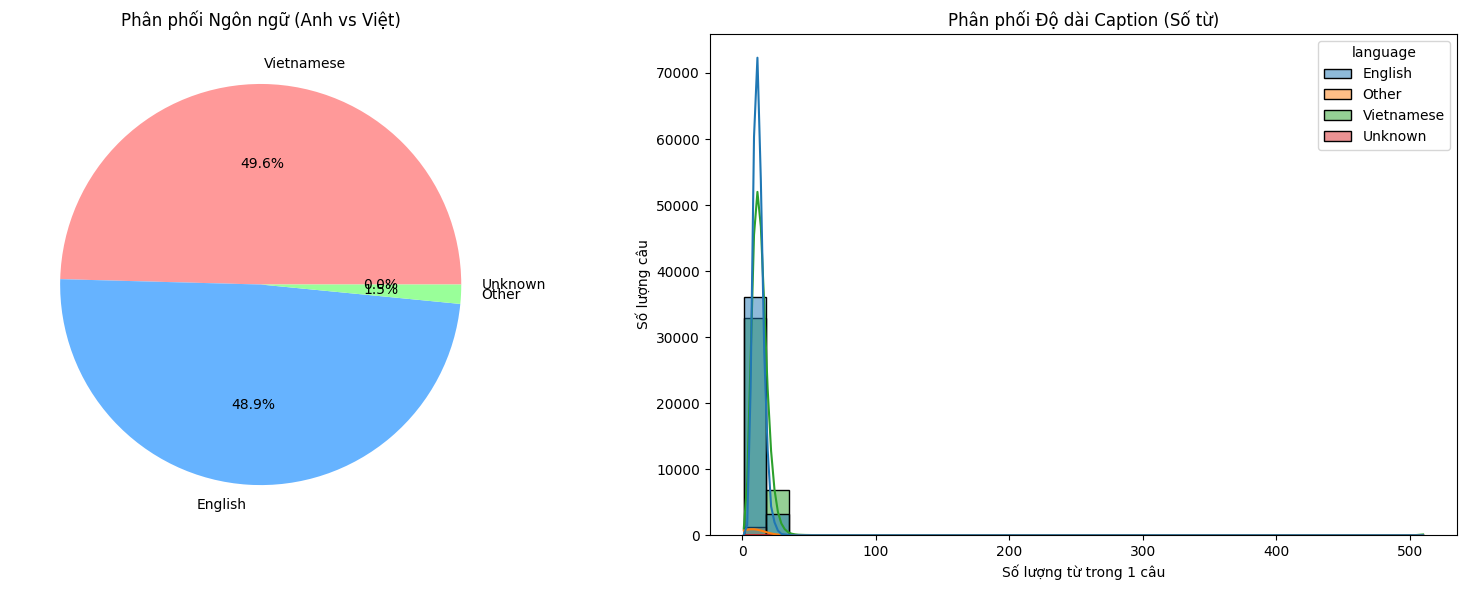

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tỷ lệ ngôn ngữ
lang_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#ff9999','#66b3ff','#99ff99'])
axes[0].set_title('Phân phối Ngôn ngữ (Anh vs Việt)')
axes[0].set_ylabel('')

# Biểu đồ 2: Phân phối độ dài từ (Histogram)
sns.histplot(df, x='word_count', hue='language', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Phân phối Độ dài Caption (Số từ)')
axes[1].set_xlabel('Số lượng từ trong 1 câu')
axes[1].set_ylabel('Số lượng câu')

plt.tight_layout()
plt.show()